# 🔍 Project Overview
This notebook presents a complete end-to-end optimization and deployment pipeline for a GPT-2-style small language model (SLM), with the goal of achieving efficient inference on resource-constrained environments.

## 📦 Part 1: Load & Profile GPT-2 in FP16 on GPU (NVIDIA T4)
- **Objective**: Load the GPT-2 model with half-precision (FP16) to reduce memory footprint and accelerate inference.

- **Hardware**: NVIDIA T4 GPU (16 GB GDDR6).

- **Tasks**:
    - Load a pretrained GPT-2 model using Hugging Face Transformers.
    - Convert weights to FP16.
    - Measure baseline performance: latency, throughput, VRAM usage.
    - Use torch.profiler to generate flame graphs for bottleneck analysis.
 

### Environment Setup
#### Hardware & Software Requirements


*   GPU: NVIDIA T4 (16 GB GDDR6 VRAM, 320 GB/s bandwidth, 320 Turing Tensor Cores)
*   CPU: 2 vCPUs, 4 GB RAM for final inference stage
*   Python Version: ≥ 3.8
*   Libraries:
    * torch
    * transformers
    * optimum
    * datasets
    * tqdm, matplotlib, and psutil for progress bars, plotting, and memory checks

### Install the libraries

We run `nvidia-smi` to check if GPU is visible and ready to use. We then install the necessary libraries. 

In [ ]:
!nvidia-smi

In [1]:
import sys
import os

# Set project root (e.g., the folder containing the notebook and .py files)
project_root = os.path.abspath('projects/model-opt/gpt2-optimization')

print(f"Project root resolved to:\n{project_root}")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.chdir(project_root)

!ls -la

Project root resolved to:
/home/oliver/project-showroom/projects/model-opt/gpt2-optimization
total 684
drwxr-xr-x 2 oliver oliver   4096 Nov 23 12:35 .
drwxr-xr-x 3 oliver oliver   4096 Nov 17 17:42 ..
-rw-r--r-- 1 oliver oliver   5945 Nov 17 18:11 README.md
-rw-r--r-- 1 oliver oliver 121950 Nov 22 09:45 demo-inspiration.ipynb
-rw-r--r-- 1 oliver oliver 317945 Nov 23 12:32 model_optimization_project.ipynb
-rw-r--r-- 1 oliver oliver 239331 Nov 17 18:21 model_optimization_project_starter.ipynb


### Logging into Huggingface and Authincating 

In [ ]:
from huggingface_hub import login
HF_TOKEN=''  # Replace with your actual Hugging Face token

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please save the token first.")

Successfully logged in to Hugging Face!


### Check for GPU

In [3]:
# Check PyTorch GPU availability and VRAM
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"CUDA Device: {gpu_name}")
    print(f"Total GPU VRAM: {total_mem:.2f} GB")
else:
    raise RuntimeError("CUDA GPU not available! Ensure a T4 is attached.")


CUDA Device: NVIDIA GeForce RTX 4070 Laptop GPU
Total GPU VRAM: 8.00 GB


**Expected Output**



```
CUDA Device: Tesla T4
Total GPU VRAM: 14.74 GB
```



###  Load GPT2 & Tokenizer

Loads a GPT-2 model and tokenizer in FP16 precision and moves the model to the appropriate device.

    How to implement:
    - Use the `transformers` library to load the tokenizer and model using the provided model ID.
    - Set the model's data type to FP16 (float16).
    - Use `torch` to detect whether a CUDA-compatible GPU is available.
    - Move the model to the selected device (GPU if available, else CPU).
    - Return both the tokenizer and model.

    Args:
        model_id (str): The model name or path to load from Hugging Face (default: "gpt2").

    Returns:
        tuple: A tuple containing the tokenizer and the model.

In [4]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def load_fp16_model(model_id="gpt2"):
    """
    Loads a GPT-2 model and tokenizer in FP16 precision and moves the model to the appropriate device.

    How to implement:
    - Use the `transformers` library to load the tokenizer and model using the provided model ID.
    - Set the model's data type to FP16 (float16).
    - Use `torch` to detect whether a CUDA-compatible GPU is available.
    - Move the model to the selected device (GPU if available, else CPU).
    - Return both the tokenizer and model.

    Args:
        model_id (str): The model name or path to load from Hugging Face (default: "gpt2").

    Returns:
        tuple: A tuple containing the tokenizer and the model.
    """
    # Load the tokenizer
    tokenizer = GPT2Tokenizer.from_pretrained(model_id)
    
    # Load the model and convert to FP16
    model = GPT2LMHeadModel.from_pretrained(model_id).half()
    
    # Detect device and move model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    print(f"Loaded model '{model_id}' in FP16 on {device}")
    
    return tokenizer, model

In [5]:
tokenizer, model = load_fp16_model()
device = model.device

Loaded model 'gpt2' in FP16 on cuda


#### Lets write a test case to see if we have successfully loaded the model. Run the below cell. **Do not change anything**

In [6]:
def test_load_fp16_model():
    # Simple test prompt
    prompt = "The future of AI is"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate text
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_length=20,
            do_sample=False
        )

    # Decode output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("\n=== Test Output ===")
    print("Prompt:", prompt)
    print("Generated:", generated_text)

    # Basic correctness checks
    assert model.dtype == torch.float16, "Model is not in FP16"
    assert str(model.device) == str(inputs["input_ids"].device), "Model and input are on different devices"
    assert prompt in generated_text, "Generated text does not include the prompt"
    print("\nTest passed ✅")


test_load_fp16_model()

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



=== Test Output ===
Prompt: The future of AI is
Generated: The future of AI is in the hands of the next generation of AI.

The future of

Test passed ✅


#### You should see an output like this

Loaded model 'gpt2' in FP16 on cuda

=== Test Output ===
Prompt: The future of AI is
Generated: The future of AI is uncertain.

The future of AI is uncertain.

The future

Test passed ✅

### Load WikiTest-2 Dataset

Loads a small subset of the WikiText-2 dataset for training and validation.

    How to implement:
    - Use the `load_dataset` function from the `datasets` library.
    - Load the "wikitext-2-raw-v1" dataset.
    - Specify the split using slice notation strings (e.g., "train[:100]").
    - Return both the training and validation subsets.
    - Optionally, print how many examples are loaded in each split.

    Args:
        train_split (str): Slice of the training data to load.
        valid_split (str): Slice of the validation data to load.

    Returns:
        tuple: A tuple containing the training and validation datasets.

In [7]:
from datasets import load_dataset

def load_wikitext_dataset(train_split="train[:100]", valid_split="validation[:200]"):
    """
    Loads a small subset of the WikiText-2 dataset for training and validation.

    How to implement:
    - Use the `load_dataset` function from the `datasets` library.
    - Load the "wikitext-2-raw-v1" dataset.
    - Specify the split using slice notation strings (e.g., "train[:100]").
    - Return both the training and validation subsets.
    - Optionally, print how many examples are loaded in each split.

    Args:
        train_split (str): Slice of the training data to load.
        valid_split (str): Slice of the validation data to load.

    Returns:
        tuple: A tuple containing the training and validation datasets.
    """
    # Load the dataset with specified splits
    train_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=train_split)
    valid_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=valid_split)
    
    # Print the number of examples loaded
    print(f"Loaded {len(train_dataset)} training examples")
    print(f"Loaded {len(valid_dataset)} validation examples")
    
    return train_dataset, valid_dataset

In [8]:
train_ds, valid_ds = load_wikitext_dataset(train_split="train[:100]", valid_split="validation[:200]")

Loaded 100 training examples
Loaded 200 validation examples


#### Lets write a test case to see if we have successfully loaded the dataset. Run the below cell. **Do not change anything**

In [9]:
def test_load_wikitext_dataset():
    print("\n=== Sample Examples ===")
    print("Train[0]:", train_ds[1]['text'])
    print("Valid[0]:", valid_ds[1]['text'])

    # Checks
    assert len(train_ds) == 100, "Train dataset does not contain 100000 samples"
    assert len(valid_ds) == 200, "Validation dataset does not contain 200 samples"
    assert isinstance(train_ds[0]['text'], str), "Train sample is not a string"
    assert isinstance(valid_ds[0]['text'], str), "Validation sample is not a string"

    print("\nTest passed ✅")

test_load_wikitext_dataset()


=== Sample Examples ===
Train[0]:  = Valkyria Chronicles III = 

Valid[0]:  = Homarus gammarus = 


Test passed ✅


#### You should see an output something like this

=== Sample Examples === \
Train[0]:  = Valkyria Chronicles III = 

Valid[0]:  = Homarus gammarus = 


Test passed ✅

### Baseline FP16 GPU Profiling

Measures the average inference latency on GPU in milliseconds per token.

    How to implement:
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Tokenize the input prompt and move it to the GPU.
    4. Perform a short warm-up generation (e.g., 10 tokens) to stabilize performance.
    5. Use `time.time()` to measure how long it takes to generate `max_new_tokens`.
    6. Use `torch.cuda.synchronize()` before and after timing to ensure accurate GPU measurements.
    7. Return the average time per token (in ms) by dividing elapsed time by `max_new_tokens`.

    Args:
        model: A causal language model loaded on GPU.
        tokenizer: The tokenizer used for encoding the input prompt.
        prompt (str): The prompt string for text generation.
        max_new_tokens (int): Number of tokens to generate during measurement.

    Returns:
        float: Latency in milliseconds per generated token.

Below this cell, implement `measure_latency_gpu(...)` step by step following the docstring hints.

In [10]:
import time
import torch
import math
from tqdm.auto import tqdm
from torch.profiler import profile, record_function, ProfilerActivity

def measure_latency_gpu(model, tokenizer, prompt, max_new_tokens=50):
    """
    Measures the average inference latency on GPU in milliseconds per token.
    How to implement:
    
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Tokenize the input prompt and move it to the GPU.
    4. Perform a short warm-up generation (e.g., 10 tokens) to stabilize performance.
    5. Use `time.time()` to measure how long it takes to generate `max_new_tokens`.
    6. Use `torch.cuda.synchronize()` before and after timing to ensure accurate GPU measurements.
    7. Return the average time per token (in ms) by dividing elapsed time by `max_new_tokens`.

    Args:
        model: A causal language model loaded on GPU.
        tokenizer: The tokenizer used for encoding the input prompt.
        prompt (str): The prompt string for text generation.
        max_new_tokens (int): Number of tokens to generate during measurement.

    Returns:
        float: Latency in milliseconds per generated token.
    """
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Put model in evaluation mode
    model.eval()
    
    # Tokenize input and move to device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    # Warm-up generation
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)
    
    # Synchronize before timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Measure generation time
    start_time = time.time()
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens)
    
    # Synchronize after generation
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    elapsed = time.time() - start_time
    
    # Calculate latency per token in milliseconds
    latency_per_token = (elapsed * 1000) / max_new_tokens
    
    return latency_per_token

In [11]:
# Measure latency using the same token-by-token loop
prompt = "The future of AI is"
max_new_tokens = 50
start_time = time.time()
baseline_latency = measure_latency_gpu(model, tokenizer, prompt)
torch.cuda.synchronize()
elapsed = time.time() - start_time
latency_per_token = (elapsed * 1000) / max_new_tokens
print(f"Greedy Generation with Progress: {latency_per_token:.2f} ms/token")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Greedy Generation with Progress: 12.93 ms/token


#### Next, lets measure the Perplexity, the following function computes the perplexity of a language model on a given dataset.

    How to implement:
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Loop through each example in the dataset.
    4. For each example:
        - Skip if the text is empty or just whitespace.
        - Tokenize the text with truncation (max length = 512).
        - Move input tensors to the appropriate device and ensure their dtype is Long.
        - Set `labels = input_ids` to compute loss for causal LM.
        - Perform a forward pass under `torch.no_grad()` to get the loss.
        - Accumulate the total loss scaled by the sequence length.
    5. After the loop, divide total loss by the total number of tokens.
    6. Return the exponential of the average loss as perplexity.
       (Avoid division by zero if all texts are skipped.)

    Args:
        model: A pretrained causal language model.
        tokenizer: Corresponding tokenizer for the model.
        dataset: A Hugging Face dataset containing a "text" field.

    Returns:
        float: The perplexity score (exp of average loss per token).

In [12]:
import torch
import math

def compute_perplexity(model, tokenizer, dataset):
    """
    Computes the perplexity of a language model on a given dataset.

    How to implement:
        1. Set the device using `torch.device`, based on CUDA availability.
        2. Put the model in evaluation mode using `.eval()`.
        3. Loop through each example in the dataset.
        4. For each example:
            - Skip if the text is empty or just whitespace.
            - Tokenize the text with truncation (max length = 512).
            - Move input tensors to the appropriate device and ensure their dtype is Long.
            - Set `labels = input_ids` to compute loss for causal LM.
            - Perform a forward pass under `torch.no_grad()` to get the loss.
            - Accumulate the total loss scaled by the sequence length.
        5. After the loop, divide total loss by the total number of tokens.
        6. Return the exponential of the average loss as perplexity.
        (Avoid division by zero if all texts are skipped.)

    Args:
        model: A pretrained causal language model.
        tokenizer: Corresponding tokenizer for the model.
        dataset: A Hugging Face dataset containing a "text" field.

    Returns:
        float: The perplexity score (exp of average loss per token).
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    with torch.no_grad():
        for example in dataset:
            text = example["text"]
            
            # Skip empty or whitespace-only text
            if not text or not text.strip():
                continue
            
            # Tokenize
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
            input_ids = inputs["input_ids"].to(model.device, dtype=torch.long)
            
            # Skip if tokenized length is 0
            if input_ids.shape[1] == 0:
                continue
            
            # Compute loss
            outputs = model(input_ids, labels=input_ids) # teacher forcing
            loss = outputs.loss
            
            # Accumulate
            total_loss += loss.item() * input_ids.shape[1]
            total_tokens += input_ids.shape[1]
    
    # Compute perplexity
    if total_tokens == 0:
        return float("inf")
    
    perplexity = math.exp(total_loss / total_tokens)
    return perplexity

_, valid_ds = load_wikitext_dataset(train_split="train[:100]", valid_split="validation[:200]")
baseline_ppl = compute_perplexity(model, tokenizer, valid_ds)
print(f"Baseline FP16 GPU Perplexity: {baseline_ppl:.2f}")

Loaded 100 training examples
Loaded 200 validation examples
Baseline FP16 GPU Perplexity: 40.02


#### Lets call the `model.generate` function to see the  VRAM usage 

In [13]:
# 3. Check peak GPU memory usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = model.generate(**tokenizer("warm up", return_tensors="pt").to(device), max_new_tokens=5)
peak_vram = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Baseline FP16 GPU Peak VRAM: {peak_vram:.2f} GB")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Baseline FP16 GPU Peak VRAM: 0.36 GB


#### Lets generate a flame graph and visualize it using Tensorboard 

In [14]:
import torch
from torch.profiler import profile, record_function, ProfilerActivity, tensorboard_trace_handler, schedule
from datetime import datetime
import os


def profile_model_for_tensorboard(model, tokenizer, prompt, device, log_dir="tb_logs", run_name="pruned_fp16"):
    """
    Profiles the inference of a PyTorch model and saves a trace for visualization in TensorBoard.

    Args:
        model (torch.nn.Module): The PyTorch model to profile.
        tokenizer: The tokenizer used to process the prompt.
        prompt (str): The input prompt string for model inference.
        device (str or torch.device): Device to run the model on ("cuda" or "cpu").
        log_dir (str): Directory where TensorBoard logs will be saved.
        run_name (str): Subdirectory name for this profiling run.

    Returns:
        None. Writes profiling logs to disk and prints the save location.
    """
    # 1) Prepare device and model
    if isinstance(device, str):
        device = torch.device(device)

    model.to(device)
    model.eval()

    # 2) Tokenize prompt and move to device
    enc = tokenizer(prompt, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}

    # 3) Build log directory for this run
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = os.path.join(log_dir, run_name, timestamp)
    os.makedirs(run_dir, exist_ok=True)
    print(f"Profiling run directory: {run_dir}")
    
    # 4) Configure profiler activities
    activities = [ProfilerActivity.CPU]
    if device.type == "cuda" and torch.cuda.is_available():
        activities.append(ProfilerActivity.CUDA)

    # 5) Optional warmup call (not profiled) so kernels are initialized
    with torch.no_grad():
        _ = model.generate(**enc, max_length=enc["input_ids"].shape[1] + 20)

    # 6) Run profiling loop
    #    Small schedule so you actually see multiple steps in the trace
    prof_schedule = schedule(
        wait=1,    # steps not recorded
        warmup=1,  # steps recorded but not saved
        active=3,  # steps recorded and saved
        repeat=1,
    )

    with profile(
        activities=activities,
        schedule=prof_schedule,
        on_trace_ready=tensorboard_trace_handler(run_dir),
        record_shapes=True,
        with_stack=True,
        profile_memory=True,
    ) as prof:
        for step in range(5):
            with torch.no_grad():
                with record_function("inference_step"):
                    _ = model.generate(**enc, max_length=enc["input_ids"].shape[1] + 20)
            prof.step()

    print(f"Profiling trace written to: {run_dir}")
    print("Start TensorBoard with:")
    print(f"  tensorboard --logdir={log_dir}")

profile_model_for_tensorboard(model, tokenizer, prompt="The future of AI is", device="cuda", run_name="baseline_fp16")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Profiling run directory: tb_logs/baseline_fp16/20251123-123638


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Profiling trace written to: tb_logs/baseline_fp16/20251123-123638
Start TensorBoard with:
  tensorboard --logdir=tb_logs


#### We will also do a profiler trace to measure the baseline inference

In [15]:
# 4. Rrecord a torch.profiler trace for baseline inference
with profile(activities=[ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("baseline_fp16_inference"):
        _ = model.generate(**tokenizer(prompt, return_tensors="pt").to(device), max_new_tokens=50)
prof.export_chrome_trace("baseline_fp16_trace.json")
print("Exported baseline_fp16_trace.json")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Exported baseline_fp16_trace.json


## ✂️ Part 2: Structured Attention Head Pruning & Fine-Tuning
**Objective:** Reduce the number of parameters by pruning redundant attention heads while maintaining accuracy.

**Methodology:**

    - Prune a fixed percentage (e.g., 20%) of attention heads per layer.
    - Fine-tune the pruned model on a small corpus to recover lost performance.

- **Metrics Tracked:**

    - Change in latency and memory usage.
    - Perplexity before and after fine-tuning.


### How do we Prune it?
1. Prune 25 % of Heads in GPT-2
GPT-2 architecture:

- Hidden size: 768
- Layers: 12 transformer blocks
- Heads per layer: 12
- Total heads: 12 × 12 = 144

Pruning plan:

- 25 % of heads ⇒ 0.25 × 12 = 3 heads removed per layer
- Remaining heads: 12 − 3 = 9 per layer ⇒ 9 × 12 = 108 total heads
- Rough parameter reduction:

    - GPT-2 has ~117 M parameters overall
    - Attention-head weights constitute ≈15 % of that (~17 M)
    - Removing 25 % of head parameters cuts ~4 M weights → new model size ≈113 M (≈3 % total reduction)

📈 Why head pruning?

- Multi-head attention learns some heads that contribute very little—pruning them can cut compute and memory.
- Warm-up and inference speed improve (often 10–20 %), with only minor losses in perplexity.

In [16]:
import random

def prune_attention_heads(model, prune_fraction=0.25, random_prune=False):
    """
    Prunes a fraction of attention heads from each layer of the model and casts it back to FP16.

    How to implement:
    1. Retrieve the number of transformer layers and the number of attention heads per layer
       using the model's configuration (e.g., `model.config.n_layer` and `model.config.n_head`).
    2. Compute how many heads to prune per layer (e.g., 20% of total heads).
    3. Construct a dictionary where each key is a layer index, and the value is a list of
       head indices to prune in that layer (e.g., [0, 1, 2, 3]).
    4. Call the `prune_heads()` method on `model.base_model` and pass the dictionary.
    5. After pruning, cast the model back to `float16` using `.half()` to reduce memory usage.

    Args:
        model: The transformer-based model with attention heads to prune.
        prune_fraction (float): The fraction of heads to prune per layer (default is 0.2 for 20%).
        random_prune: If True, randomly selects heads to prune. 
                      If False, selects lowest indexed heads (not recommended - but must be used here).

    Returns:
        The pruned model in float16.
    """
    n_layer = model.config.n_layer
    n_head = model.config.n_head

    prune_per_layer = int(n_head * prune_fraction)
    if prune_per_layer == 0:
        print("Nothing to prune")
        return model

    heads_to_prune = {}

    for layer in range(n_layer):

        if random_prune:
            selected = random.sample(range(n_head), prune_per_layer)
        else:
            selected = list(range(prune_per_layer))

        heads_to_prune[layer] = selected

    # GPT-2 supports pruning through the top-level API
    model.prune_heads(heads_to_prune)

    # Cast back to FP16 if desired
    model = model.half()

    print(f"Pruned {prune_per_layer} heads per layer out of {n_head}")
    return model

model = prune_attention_heads(model, prune_fraction=0.2)

Pruned 2 heads per layer out of 12


### Lets write a test case to see if we have successfully pruned the model. Run the below cell. Do not change anything

In [17]:
import torch
from transformers import GPT2LMHeadModel

def test_prune_attention_heads(pruned_model):
    # 1) Load GPT-2 small in FP16
    #model = GPT2LMHeadModel.from_pretrained("gpt2").half().to("cpu")
        
    orig_n_head  = model.config.n_head    # 12
    orig_n_layer = model.config.n_layer   # 12
    prune_fraction = 0.2                  # 20%
    heads_pruned = int(orig_n_head * prune_fraction)  # floor(12 * 0.2) = 2
    expected_heads = orig_n_head - heads_pruned       # 12 - 2 = 10
    
    # 2) Apply pruning
    #pruned_model = prune_attention_heads(model, prune_fraction=prune_fraction)
    
    # 3) All params still float16
    for p in pruned_model.parameters():
        assert p.dtype == torch.float16, "⚠️ Parameter not in float16"
    
    # 4) Check each layer’s Attention module
    for i in range(orig_n_layer):
        attn = pruned_model.transformer.h[i].attn
        
        # num_heads should be reduced
        assert attn.num_heads == expected_heads, (
            f"Layer {i} has {attn.num_heads} heads, expected {expected_heads}"
        )
        
        # pruned_heads set should match {0, 1, …, heads_pruned-1}
        assert attn.pruned_heads == set(range(heads_pruned)), (
            f"Layer {i} pruned {attn.pruned_heads}, expected {set(range(heads_pruned))}"
        )
    
    print("test_prune_attention_heads passed ✅")

# Run it
test_prune_attention_heads(model)


test_prune_attention_heads passed ✅


#### You should see an output something like this

Pruned 20% of heads per layer\
test_prune_attention_heads passed ✅

> Remark: I don't understand the "test". The test creates a new model, prunes it and then checks. It is not tested against my pruned model. I changed the code so my model is tested.

### How do we Fine-Tune the Pruned Model for 1 Epoch :


Here we will:

1. **Configure the tokenizer & model**  
   - Reuse the EOS token for padding so that causal LM padding behaves correctly.  
   - Ensure `pad_token_id` is set in both the tokenizer and model config.

2. **Prepare the data**  
   - Tokenize and truncate each example to a fixed length (max 512 tokens).  
   - Copy the inputs to `labels` for next-token prediction.  
   - Use `DataCollatorForLanguageModeling` (with `mlm=False`) to dynamically batch sequences for causal LM.

3. **Set up training arguments**  
   - Disable external logging (`WANDB_DISABLED` and `report_to="none"`).  
   - Choose hyperparameters: epochs, batch size, learning rate, logging frequency.  
   - Enable FP16 training via `fp16=True` under the hood.

4. **Handle precision & device placement**  
   - Cast the pruned model back to FP32 (`model.float()`) before handing off to the Trainer.  
   - Let the Trainer automatically manage FP16 conversion, gradient scaling, and device transfers.

5. **Launch training**  
   - Instantiate a `Trainer` with the pruned model, tokenized dataset, and collator.  
   - Call `trainer.train()` to fine-tune on your custom text split.

> 🔧 **Learning Objectives**  
> - See how to integrate pruned models into a standard 🤗 Trainer workflow  
> - Understand padding for causal LMs and label shifting  
> - Observe mixed-precision training setup and benefits  

In [18]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import os
import torch # Import torch explicitly

os.environ["WANDB_DISABLED"] = "true"

def prepare_tokenizer_for_padding(tokenizer, model):
    """
    Prepares the tokenizer and model for consistent padding behavior during fine-tuning.

    How to implement:
    - Set the tokenizer's pad token to be the same as its end-of-sequence (eos) token.
    - Update the model's configuration to use this same pad token ID.

    Args:
        tokenizer: The Hugging Face tokenizer.
        model: The language model whose config needs to be updated.

    Returns:
        None (modifies tokenizer and model in-place)
    """
    # Set pad token to eos token
    tokenizer.pad_token = tokenizer.eos_token
    
    # Update model config
    model.config.pad_token_id = tokenizer.pad_token_id

#prepare_tokenizer_for_padding(tokenizer, model)

In [19]:
def tokenize_dataset(dataset, tokenizer):
    """
    Tokenizes a dataset of text examples for causal language modeling.

    How to implement:
    - Use `tokenizer` to tokenize the "text" field.
    - Truncate examples to a maximum length (e.g., 512 tokens).
    - Pad sequences using max length.
    - Copy `input_ids` to a new key `labels` for causal language modeling.
    - Remove the raw "text" column from the result.

    Args:
        dataset: Hugging Face Dataset containing a "text" field.
        tokenizer: The tokenizer to use.

    Returns:
        A tokenized dataset suitable for training.
    """
    def tokenize_function(examples):
        # Tokenize with truncation and padding
        result = tokenizer(
            examples["text"],
            truncation=True,
            max_length=512,
            padding="max_length",
            return_tensors=None
        )
        # Copy input_ids to labels for causal LM
        result["labels"] = result["input_ids"].copy()
        return result
    
    # Map tokenization function over dataset
    tokenized = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"]
    )
    
    return tokenized

#tokenized_train = tokenize_dataset(train_ds, tokenizer)

In [20]:
def create_training_arguments(output_dir="gpt2_finetuned", learning_rate=1e-5):
    """
    Creates Hugging Face TrainingArguments for model fine-tuning.

    How to implement:
    - Set a small batch size (e.g., 1–2) to handle large models.
    - Use 1 epoch for quick experimentation.
    - Disable saving and logging to external tools (e.g., wandb).
    - Disable column removal to retain all inputs.

    Args:
        output_dir (str): Directory to save model outputs.
        learning_rate (float): Learning rate for fine-tuning.

    Returns:
        TrainingArguments object.
    """
    
    training_args = TrainingArguments(        
        output_dir=output_dir,       
        num_train_epochs=5,       
        per_device_train_batch_size=2,        
        gradient_accumulation_steps=4,        
        evaluation_strategy="no",       
        learning_rate=learning_rate,        
        fp16=True,       
        save_only_model=True,        
        save_total_limit=1,        
        report_to=[],                
        logging_steps=50,        
        logging_strategy="steps",      
        save_strategy="no",        
        remove_unused_columns=False    
)
    return training_args

In [21]:
def run_fine_tuning(model, training_args, tokenized_train, tokenizer):
    """
    Fine-tunes the given model using the Hugging Face Trainer.

    How to implement:
    - Set up a data collator for language modeling (no masked LM).
    - Initialize the Trainer with model, args, dataset, and collator.
    - Call `.train()` to begin fine-tuning.

    Args:
        model: The transformer model to fine-tune.
        training_args: TrainingArguments object.
        tokenized_train: Tokenized training dataset.
        tokenizer: Tokenizer used to create the collator.

    Returns:
        Trainer instance after training.
    """
    # Create data collator for causal language modeling
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False  # No masked language modeling
    )
    
    model = model.float()  # Ensure model is in float32 for training stability
    #model.to("cuda")  # Move model to GPU if available

    # Initialize trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        data_collator=data_collator
    )
    
    # Start training
    trainer.train()
    
    return trainer

#### Lets call of these functions to finetune the pruned model

In [22]:
train_ds, valid_ds = load_wikitext_dataset(train_split="train[:800]", valid_split="validation[:200]")
prepare_tokenizer_for_padding(tokenizer, model)
tokenized_train = tokenize_dataset(train_ds, tokenizer)
tokenized_valid = tokenize_dataset(valid_ds, tokenizer)
training_args = create_training_arguments(learning_rate=1e-05)
trainer = run_fine_tuning(model, training_args, tokenized_train, tokenizer) # runs a full fine-tuning, no weights were freezed

Loaded 800 training examples
Loaded 200 validation examples


/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss
50,11.238400
100,6.421600
150,5.969400
200,5.370100
250,5.483600
300,5.567200
350,6.320500
400,5.505400
450,4.933600
500,6.116800


### Benchmark Pruned Model on GPU:

After fine-tuning, re-measure latency, perplexity, and GPU VRAM usage for the pruned FP16 model using the same functions we wrote above to measure latency etc.

In [23]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import time

start_time = time.time()
pruned_latency = measure_latency_gpu(model, tokenizer, prompt)
torch.cuda.synchronize()
elapsed = time.time() - start_time
latency_per_token = (elapsed * 1000) / max_new_tokens
print(f"Pruned GPU Latency: {latency_per_token:.2f} ms/token")

pruned_ppl = compute_perplexity(model, tokenizer, valid_ds)
print(f"Pruned GPU Perplexity: {pruned_ppl:.2f}")

_ = model.generate(**tokenizer("warm up", return_tensors="pt").to(device), max_new_tokens=5)
pruned_vram = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Pruned GPU Peak VRAM: {pruned_vram:.2f} GB")

profile_model_for_tensorboard(model, tokenizer, prompt="The future of AI is", device="cuda", run_name="pruned_fp16")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Pruned GPU Latency: 21.03 ms/token


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Pruned GPU Perplexity: 33.06
Pruned GPU Peak VRAM: 3.51 GB
Profiling run directory: tb_logs/pruned_fp16/20251123-124140


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Profiling trace written to: tb_logs/pruned_fp16/20251123-124140
Start TensorBoard with:
  tensorboard --logdir=tb_logs


### 📘 Interpretation of Pruning Results and Critical Reflection

After performing pruning and full-parameter finetuning according to the project instructions, the final measurements were:

* **Unoptimized Model**

  * GPU Latency per Token: **12.02 ms/token**
  * Perplexity: **40.3**

* **Pruned Model (20% attention heads removed)**

  * GPU Latency per Token: **19.16 ms/token**
  * Perplexity: **33.05**

At first glance, this seems contradictory: pruning should reduce computation, yet latency increased, while perplexity slightly improved.
However, when analyzed in the context of the model architecture and training setup, these results actually make sense.

Below is a concise interpretation.

---

#### 1. Perplexity Did Not Increase Because Finetuning Dominated the Outcome

In this project workflow, pruning is followed by **full-model finetuning on a very small dataset** (~800 samples).
Finetuning all 117M GPT-2 parameters on such a small dataset causes the model to:

* adapt strongly to the specific validation distribution
* partially memorize patterns
* reduce loss on the dataset used for evaluation
* mask the negative effects of pruning

As a result:

> The slight decrease in perplexity (40.3 → 36.6) reflects the finetuning signal,
> not an improvement caused by pruning.

This means perplexity is **not a reliable indicator of model quality** in this experiment.

---

#### 2. Latency Increased Because Head Pruning Does Not Reduce Compute in GPT-2

The Hugging Face GPT-2 implementation is not optimized for actual compute-efficient head removal.
Pruning attention heads only:

* removes weight slices
* adjusts internal indexing
* but **does not shrink attention matrices**
* does **not** reduce tensor shapes
* does **not** change the fused GPU kernels
* may introduce masking or indexing overhead

Therefore:

> Pruning heads does not reduce FLOPs in this architecture.
> In practice, it can even make execution slower.

This explains why latency went from 12.02 ms/token to 22.32 ms/token.

---

#### 3. Combined Effect: Metrics Cannot Isolate the True Impact of Pruning

Because:

* the dataset is extremely small
* pruning is arbitrary (lowest head indices removed)
* full finetuning happens afterward
* GPT-2 is not structured for hardware-aware pruning
* evaluation is on the same domain as finetuning
* perplexity is measured on only ~200 samples

the final metrics mostly reflect:

> noise introduced by small data and full finetuning,
> not the structural effect of pruning.

In other words:

* **The increase in latency is architectural.**
* **The decrease in perplexity is procedural (finetuning), not a pruning benefit.**
* **The experiment setup prevents meaningful pruning evaluation.**

---

#### 4. What These Results Really Tell Us

The correct interpretation is:

> Under this project’s constraints, pruning attention heads in GPT-2
> does not speed up inference and does not meaningfully impact perplexity.
> The finetuning step dominates the model’s behavior,
> and the pruning step does not produce measurable computational benefits.

This is not a training failure—
it is simply a consequence of evaluating pruning in a context where the architecture and setup do not allow for clear or realistic results.

---

In [24]:
# 4. Torch profiler trace for pruned inference
with profile(activities=[ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("pruned_fp16_inference"):
        _ = model.generate(**tokenizer(prompt, return_tensors="pt").to(device), max_new_tokens=50)
prof.export_chrome_trace("pruned_fp16_trace.json")
print("Exported pruned_fp16_trace.json")  # :contentReference[oaicite:12]{index=12}


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Exported pruned_fp16_trace.json


### 📘 Technical Log: Why My First Fine-Tuning Attempt Caused Catastrophic Forgetting — And How I Stabilized GPT-2

During this project, I experimented with different fine-tuning strategies for GPT-2.
My first attempt followed the instructions very literally, but the results were severe: the model completely collapsed after a few training steps.

Below is a summary of what happened, why it happened, and what fixed it.

---

#### 1. My First Attempt: Why Catastrophic Forgetting Happened

In my initial setup, I did the following:

* **Converted the entire model to FP16 manually** using `.half()`
* **Used batch size = 1**
* **No gradient accumulation**
* **Only ~100 training records**
* **Learning rate = 1e-5**
* **Pruned several attention heads before fine-tuning**
* **Trained the full 117M GPT-2 parameters**

This combination created the perfect storm for catastrophic forgetting.

##### 1.1 Why FP16 weights were a major problem

With `.half()`, all model weights and gradients were stored in FP16, which:

* has only 10 bits of mantissa
* produces coarse, imprecise parameter updates
* amplifies noisy gradients
* easily underflows or overflows during backprop

This means:

> Even a single gradient step can shove the weights far away from their pretrained optimum.

This immediately destabilizes internal attention patterns and MLP activations.

##### 1.2 Why tiny datasets produce destructive gradients

With only ~100 samples:

* gradients represent a **very narrow** slice of language
* updates are dominated by noise
* the model tries to *memorize* instead of generalize
* this pulls the weights violently toward the micro-dataset

##### 1.3 Why batch size = 1 makes everything worse

A batch of size 1 produces **extremely high variance gradients**.
In LLMs, high variance gradients are catastrophic.

##### 1.4 The result

With all factors combined:

* training loss dropped to **0** after a few steps
* validation perplexity became unstable or NaN
* the model began repeating or producing incoherent text
* the underlying pretrained structure was overwritten

This was textbook catastrophic forgetting.

---

#### 2. What Fixed the Problem: FP32 Master Weights + AMP + Accumulation

After discussing with a mentor, I switched to a more stable configuration:

##### ✔ Converted the model **back to FP32** before fine-tuning

##### ✔ Enabled **fp16=True** in TrainingArguments (AMP, not manual FP16)

##### ✔ Used **gradient_accumulation_steps = 4**

##### ✔ Used **batch size = 2**

##### ✔ Used **800 training examples**

This made the training stable.

Let’s unpack *why*.

---

#### 3. Why Casting Back to FP32 Was the Key Factor

This turned out to be the single most important fix.

##### 3.1 FP32 weights provide fine-grained, stable updates

FP32 has:

* 23 bits of mantissa
* high numerical precision
* smooth gradients
* stable optimizer behavior

So:

> FP32 weights absorb small gradients gently instead of jumping around.

This **protects** the pretrained weight geometry that GPT-2 relies on.

---

#### 4. Why AMP FP16 (in TrainingArguments) Is Safe, While Manual FP16 Was Destructive

This is critical:

##### ❌ Manual FP16 (`model.half()`)

* Weights are FP16
* Gradients are FP16
* No loss scaling
* No overflow protection
* No FP32 master copy
* No unscaling step

Result:
**Rapid destruction of pretrained knowledge.**

##### ✔ AMP FP16 (`fp16=True` in TrainingArguments)

AMP uses:

* **FP32 master weights** (always!)
* **FP16 compute** for speed
* **Gradient scaling** to avoid underflow
* **Unscaling + clipping** to avoid overflow
* **Stability checks** before updating weights

Result:
**Fast training with stable weights.**

In other words:

> With AMP, the model *acts* like FP16 during forward/backward,
> but the parameters behave like FP32 during updates.

This was the *big difference* that saved the model.

---

#### 5. Why Gradient Accumulation Helped

With:

```python
gradient_accumulation_steps = 4
per_device_train_batch_size = 2
```

the effective batch size becomes:

> **8 samples per optimizer step**

This dramatically reduces gradient variance.

Low variance updates are essential for tiny datasets; otherwise the model gets “jerked around” by noisy gradients.

---

#### 6. Why 800 Samples Are More Stable Than 100

Still tiny, but:

* more diverse tokens
* more stable gradients
* less destructive updates
* more consistent loss landscape

It still overfits eventually, but *not instantly*.

---

#### ✔ Final Takeaway: Why the New Setup Works

**The biggest improvement came from restoring FP32 master weights.**
Everything else (accumulation, AMP, batch size) added stability on top.

Your original configuration:

* FP16 weights
* tiny data
* noisy gradients
* full finetuning

was like giving GPT-2 a concussion.

The new configuration:

* FP32 master weights
* AMP FP16 compute
* accumulation
* small (but not microscopic) dataset

lets you perform full finetuning **gently**, even with small data.

---

Let's save the pruned model for later use.

In [25]:
save_dir = "gpt2_finetuned"

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model + tokenizer saved to: {save_dir}")


Model + tokenizer saved to: gpt2_finetuned


## 🧮 Part 3: Post-Training Quantization (PTQ) to 8-bit

- Objective: Further compress the pruned model using 8-bit quantization for CPU-friendly deployment.

- Tools Used: Optimum Intel / Neural Compressor (INC).

- Tasks:

    - Apply static quantization to the fine-tuned model.



Here is the code for reloading the finetuned model:

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

load_dir = "gpt2_finetuned"

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(load_dir)

# Load model
model = GPT2LMHeadModel.from_pretrained(load_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Loaded fine-tuned model from {load_dir} on {device}")

Let us inspect the GPT-2 model:

In [26]:
def print_model_structure(model):
    """
    Prints the full hierarchical structure of a PyTorch model.
    Shows each module with a dotted name, e.g.:
    transformer.h.0.attn.c_attn
    transformer.h.0.mlp.c_fc
    lm_head
    """
    for name, module in model.named_modules():
        print(f"{name:40s}  ->  {module.__class__.__name__}")

print_model_structure(model)

                                          ->  GPT2LMHeadModel
transformer                               ->  GPT2Model
transformer.wte                           ->  Embedding
transformer.wpe                           ->  Embedding
transformer.drop                          ->  Dropout
transformer.h                             ->  ModuleList
transformer.h.0                           ->  GPT2Block
transformer.h.0.ln_1                      ->  LayerNorm
transformer.h.0.attn                      ->  GPT2Attention
transformer.h.0.attn.c_attn               ->  Conv1D
transformer.h.0.attn.c_proj               ->  Conv1D
transformer.h.0.attn.attn_dropout         ->  Dropout
transformer.h.0.attn.resid_dropout        ->  Dropout
transformer.h.0.ln_2                      ->  LayerNorm
transformer.h.0.mlp                       ->  GPT2MLP
transformer.h.0.mlp.c_fc                  ->  Conv1D
transformer.h.0.mlp.c_proj                ->  Conv1D
transformer.h.0.mlp.act                   ->  NewGELUActi

We define a helper function to build an op name dictionary specific for the GPT-2 model:

In [27]:
import torch.nn as nn
from neural_compressor.config import PostTrainingQuantConfig

def build_gpt2_op_name_dict(model):
    """
    Build an op_name_dict for GPT-2 that:
      - keeps embeddings, LayerNorms, and lm_head in FP32
      - quantizes internal Conv1D/Linear weights in transformer blocks to INT8
      - keeps activations in FP32 (conservative)
    """
    op_name_dict = {}

    for name, module in model.named_modules():

        # 1) Embeddings: keep FP32
        if isinstance(module, nn.Embedding):
            op_name_dict[name] = {
                "weight": {"dtype": ["fp32"]},
            }
            continue

        # 2) LayerNorm: keep FP32
        if isinstance(module, nn.LayerNorm):
            op_name_dict[name] = {
                "weight": {"dtype": ["fp32"]},
                "activation": {"dtype": ["fp32"]},
            }
            continue

        # 3) Output head: lm_head → keep FP32
        if name == "lm_head":
            if isinstance(module, nn.Linear):
                op_name_dict[name] = {
                    "weight": {"dtype": ["fp32"]},
                    "activation": {"dtype": ["fp32"]},
                }
            continue

        # 4) Internal affine transforms: Conv1D / Linear inside transformer blocks
        #    Those are the attention and MLP projections.
        is_linear_like = isinstance(module, nn.Linear) or module.__class__.__name__ == "Conv1D"

        if is_linear_like and name.startswith("transformer.h."):
            # Conservative: INT8 weights, FP32 activations
            op_name_dict[name] = {
                "weight": {"dtype": ["int8"]},
                "activation": {"dtype": ["fp32"]},
            }

    return op_name_dict

Let's test it (don't forget to load the model from disk first):

In [28]:
op_name_dict = build_gpt2_op_name_dict(model)
print("Will quantize (int8 weights):")
for name, cfg in op_name_dict.items():
    if cfg.get("weight", {}).get("dtype") == ["int8"]:
        print("  ", name)

Will quantize (int8 weights):
   transformer.h.0.attn.c_attn
   transformer.h.0.attn.c_proj
   transformer.h.0.mlp.c_fc
   transformer.h.0.mlp.c_proj
   transformer.h.1.attn.c_attn
   transformer.h.1.attn.c_proj
   transformer.h.1.mlp.c_fc
   transformer.h.1.mlp.c_proj
   transformer.h.2.attn.c_attn
   transformer.h.2.attn.c_proj
   transformer.h.2.mlp.c_fc
   transformer.h.2.mlp.c_proj
   transformer.h.3.attn.c_attn
   transformer.h.3.attn.c_proj
   transformer.h.3.mlp.c_fc
   transformer.h.3.mlp.c_proj
   transformer.h.4.attn.c_attn
   transformer.h.4.attn.c_proj
   transformer.h.4.mlp.c_fc
   transformer.h.4.mlp.c_proj
   transformer.h.5.attn.c_attn
   transformer.h.5.attn.c_proj
   transformer.h.5.mlp.c_fc
   transformer.h.5.mlp.c_proj
   transformer.h.6.attn.c_attn
   transformer.h.6.attn.c_proj
   transformer.h.6.mlp.c_fc
   transformer.h.6.mlp.c_proj
   transformer.h.7.attn.c_attn
   transformer.h.7.attn.c_proj
   transformer.h.7.mlp.c_fc
   transformer.h.7.mlp.c_proj
   transfo

#### Run PTQ with Hugging Face Optimum (Intel Backend)
First let us define an eval function for the quantizer, so the quantizer can evaluate the quantized models:

In [29]:
import torch
from torch.utils.data import DataLoader

def build_inc_eval_fn(tokenizer, valid_ds, max_eval_samples=200, max_length=128, batch_size=4):
    # 1) Subset for speed
    if max_eval_samples is not None and len(valid_ds) > max_eval_samples:
        eval_raw = valid_ds.select(range(max_eval_samples))
    else:
        eval_raw = valid_ds

    # 2) Tokenize
    def tokenize_eval(examples):
        enc = tokenizer(
            examples["text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors=None,
        )
        # We will set labels later so we can mask pads cleanly
        return enc

    tokenized_eval = eval_raw.map(
        tokenize_eval,
        batched=True,
        remove_columns=["text"],
    )

    # 3) DataLoader
    def collate_fn(features):
        batch = {}
        for key in features[0].keys():
            batch[key] = torch.tensor([f[key] for f in features])
        return batch

    eval_loader = DataLoader(
        tokenized_eval,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    def eval_fn(model):
        model.eval()
        model.to("cpu")
        losses = []

        with torch.no_grad():
            for batch in eval_loader:
                batch = {k: v.to("cpu") for k, v in batch.items()}

                input_ids = batch["input_ids"]
                attention_mask = batch.get("attention_mask", torch.ones_like(input_ids))

                # Create labels and mask out padding
                labels = input_ids.clone()
                labels[attention_mask == 0] = -100

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )

                losses.append(outputs.loss.item())

        if not losses:
            return 0.0

        avg_loss = sum(losses) / len(losses)

        # INC expects "higher is better"
        return -avg_loss

    return eval_fn


In [30]:
_, valid_ds = load_wikitext_dataset(train_split="train[:100]", valid_split="validation[:200]")
eval_fn = build_inc_eval_fn(tokenizer, valid_ds, max_eval_samples=200, max_length=128, batch_size=4)
print(eval_fn(model))

Loaded 100 training examples
Loaded 200 validation examples


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

-3.572184262275696


> So with this setup the loss of 3.572 aligns perfectly with the perplexity 33.1 from the perplexity measurement of the pruned and finetuned model.

We prepare a calibration dataset and a quantizer configuration:

In [31]:
def prepare_calibration_dataset(valid_ds, tokenizer):
    """
    Prepares a tokenized calibration dataset for INT8 post-training quantization.

    How to implement:
    - Filter out empty or whitespace-only text entries.
    - Tokenize using `tokenizer` with truncation, padding to max length (e.g., 512).
    - Remove the raw "text" column after tokenization.

    Args:
        valid_ds: A Hugging Face dataset with a "text" field.
        tokenizer: Tokenizer used for encoding.

    Returns:
        Dataset: Tokenized and ready-to-use calibration dataset.
    """
    # Filter out empty or whitespace-only text
    filtered_ds = valid_ds.filter(lambda x: x["text"] and x["text"].strip())
    
    # Tokenize the dataset
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=512,
            padding="max_length",
            return_tensors=None
        )
    
    tokenized_ds = filtered_ds.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"]
    )
    
    return tokenized_ds

def run_post_training_quantization(quantizer, calibration_dataset, output_dir):
    """
    Runs static 8-bit quantization using Intel Neural Compressor.

    How to implement:
    - Create a `PostTrainingQuantConfig` object with:
        - `approach="static"`
        - `device="cpu"`
    - Call `quantizer.quantize(...)` with calibration data and save path.

    Args:
        quantizer (INCQuantizer): The quantizer object created from the model.
        calibration_dataset: Tokenized dataset used for calibration.
        output_dir (str): Directory to save the quantized model (OpenVINO IR format).

    Returns:
        None
    """
        
    from neural_compressor.config import PostTrainingQuantConfig

    quant_config = PostTrainingQuantConfig(
        approach="static",
        device="cpu",
        op_name_dict = {
            # Keep embeddings in fp32
            "transformer.wte": {
                "weight": {"dtype": ["fp32"]},
                "activation": {"dtype": ["fp32"]},
            },
            "transformer.wpe": {
                "weight": {"dtype": ["fp32"]},
                "activation": {"dtype": ["fp32"]},
            },

            # Allow int8 for attention and MLP linears
            "attn.c_attn": {
                "weight": {"dtype": ["int8"]},
                "activation": {"dtype": ["int8"]},
            },
            "attn.c_proj": {
                "weight": {"dtype": ["int8"]},
                "activation": {"dtype": ["int8"]},
            },
            "mlp.c_fc": {
                "weight": {"dtype": ["int8"]},
                "activation": {"dtype": ["int8"]},
            },
            "mlp.c_proj": {
                "weight": {"dtype": ["int8"]},
                "activation": {"dtype": ["int8"]},
            },
        }

        

        # quant_format="QDQ",        # or "qat" if QDQ fails
        # backend="default",               # ipex was broken in your env, so stay with default
        # calibration_sampling_size=[256], # or 512 if you can afford it
        
        # # use the custom op_name_dict
        # op_name_dict=op_name_dict,

        # # do not quantize Embeddings and LayerNorms
        # op_type_dict = {
        #     "Embedding": {
        #         "weight": {"dtype": ["fp32"]},
        #         "activation": {"dtype": ["fp32"]},
        #     },
        #     "LayerNorm": {
        #         "weight": {"dtype": ["fp32"]},
        #         "activation": {"dtype": ["fp32"]},
        #     },
        # },

        # recipes={
        #     # Keep it off for now, you already saw SmoothQuant making things weird
        #     "smooth_quant": False,
        # },
    )

     # Run quantization
    quantizer.quantize(
        quantization_config=quant_config,
        calibration_dataset=calibration_dataset,
        save_directory=output_dir,
        remove_unused_columns=False,  # we already produced the right columns
    )
    
    print(f"Quantized model saved to {output_dir}")

Let us check the calibration dataset:

In [32]:
def inspect_calibration_dataset(tokenizer, calib_ds, num_samples=3):
    """
    Verifies that the calibration dataset uses the correct (prepared) tokenizer.
    Prints several internal checks and sample decoded rows.
    """
    print("=== TOKENIZER CHECK ===")
    print(f"tokenizer.pad_token:      {tokenizer.pad_token}")
    print(f"tokenizer.eos_token:      {tokenizer.eos_token}")
    print(f"tokenizer.pad_token_id:   {tokenizer.pad_token_id}")
    print(f"tokenizer.eos_token_id:   {tokenizer.eos_token_id}")
    print(f"pad_token_id == eos_token_id  -> {tokenizer.pad_token_id == tokenizer.eos_token_id}")
    print()

    # Check presence of pad tokens inside calibration samples
    print("=== CALIBRATION DATASET CHECK ===")
    print(f"Dataset length: {len(calib_ds)}")
    print(f"Columns present: {list(calib_ds.column_names)}")
    print()

    # Inspect first few examples
    print(f"=== SAMPLE INSPECTION (first {num_samples}) ===")
    for i in range(min(num_samples, len(calib_ds))):
        sample = calib_ds[i]
        input_ids = sample["input_ids"]
        attn_mask = sample.get("attention_mask", None)

        pad_id = tokenizer.pad_token_id
        num_pads = sum(1 for x in input_ids if x == pad_id)

        print(f"--- Sample {i} ---")
        print(f"input_ids length: {len(input_ids)}")
        print(f"number of pad tokens: {num_pads}")

        if attn_mask is not None:
            print(f"attention_mask sum: {sum(attn_mask)} (non padded tokens)")
        else:
            print("No attention_mask in dataset")

        # Show the first 40 tokens for clarity
        print("input_ids (first 40):", input_ids[:40])

        # Decode but ignore pad tokens to avoid clutter
        decoded = tokenizer.decode([tok for tok in input_ids if tok != pad_id])
        print("decoded (no pads):")
        print(decoded)
        print()

    print("=== CHECK COMPLETE ===")

calib_ds = prepare_calibration_dataset(valid_ds, tokenizer)

inspect_calibration_dataset(tokenizer, calib_ds)

=== TOKENIZER CHECK ===
tokenizer.pad_token:      <|endoftext|>
tokenizer.eos_token:      <|endoftext|>
tokenizer.pad_token_id:   50256
tokenizer.eos_token_id:   50256
pad_token_id == eos_token_id  -> True

=== CALIBRATION DATASET CHECK ===
Dataset length: 133
Columns present: ['input_ids', 'attention_mask']

=== SAMPLE INSPECTION (first 3) ===
--- Sample 0 ---
input_ids length: 512
number of pad tokens: 503
attention_mask sum: 9 (non padded tokens)
input_ids (first 40): [796, 8074, 20272, 9106, 3876, 385, 796, 220, 198, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]
decoded (no pads):
 = Homarus gammarus = 


--- Sample 1 ---
input_ids length: 512
number of pad tokens: 355
attention_mask sum: 157 (non padded tokens)
input_ids (first 40): [8074, 20272, 9106, 3876, 385, 837, 1900, 355, 262, 3427, 43657, 393, 2219, 43657

This is the quantizer code:

In [33]:
from optimum.intel.neural_compressor import INCQuantizer
#from datasets import load_dataset, Dataset
from neural_compressor.config import PostTrainingQuantConfig 
#from datasets import Dataset 

_, valid_ds = load_wikitext_dataset(train_split="train[:800]", valid_split="validation[:200]")

# We must comment out the eval_fn, see report below for reasons.
# eval_fn = build_inc_eval_fn(tokenizer, valid_ds, max_eval_samples=200)

# eval the model on CPU before quantization
model.to("cpu")
baseline_loss = eval_fn(model)
print(f"Baseline FP32 CPU Negative Avg Loss: {baseline_loss:.4f}")

# (A) Create the quantizer
quantizer = INCQuantizer.from_pretrained(
    model, 
    # eval_fn=eval_fn, see report for reasons
    task="text-generation"
) 
   
#op_name_dict = build_gpt2_op_name_dict(model)
calibration_dataset = prepare_calibration_dataset(valid_ds, tokenizer)
run_post_training_quantization(
    quantizer, 
    calibration_dataset, 
    output_dir='gpt2_pruned_int8', 
)

for name, module in model.named_modules():
    if isinstance(module, torch.nn.Embedding):
        print(name, module.weight.dtype)

2025-11-23 12:43:50 [WARNING][auto_accelerator.py:454] Auto detect accelerator: CUDA_Accelerator.
2025-11-23 12:43:50 [WARNING][auto_accelerator.py:454] Auto detect accelerator: CUDA_Accelerator.
2025-11-23 12:43:50 [WARNING][fp_utils.py:127] hw aligned scales not supported for device INCAcceleratorType.CUDA


Loaded 800 training examples
Loaded 200 validation examples
Baseline FP32 CPU Negative Avg Loss: -3.5722


2025-11-23 12:44:22 [INFO][logger.py:114] Start auto tuning.
2025-11-23 12:44:22 [INFO][logger.py:114] Execute the tuning process due to detect the evaluation function.
2025-11-23 12:44:22 [INFO][logger.py:114] Adaptor has 5 recipes.
2025-11-23 12:44:22 [INFO][logger.py:114] 0 recipes specified by user.
2025-11-23 12:44:22 [INFO][logger.py:114] 3 recipes require future tuning.
2025-11-23 12:44:22 [INFO][logger.py:114] *** Initialize auto tuning
2025-11-23 12:44:22 [INFO][logger.py:112] {
2025-11-23 12:44:22 [INFO][logger.py:112]     'PostTrainingQuantConfig': {
2025-11-23 12:44:22 [INFO][logger.py:112]         'AccuracyCriterion': {
2025-11-23 12:44:22 [INFO][logger.py:112]             'criterion': 'relative',
2025-11-23 12:44:22 [INFO][logger.py:112]             'higher_is_better': True,
2025-11-23 12:44:22 [INFO][logger.py:112]             'tolerable_loss': 0.01,
2025-11-23 12:44:22 [INFO][logger.py:112]             'absolute': None,
2025-11-23 12:44:22 [INFO][logger.py:112]         

Quantized model saved to gpt2_pruned_int8
transformer.wte torch.float32
transformer.wpe torch.float32


> Please read my 'Concluding Report' about the results in the following sections.

## 🚀 Part 4: Deploy on CPU-Only Machine (2 vCPUs, 4 GB RAM)
Objective: Run the quantized GPT-2 on a low-resource edge device.

Environment:

2-core CPU

4 GB RAM

Tasks:

Measure latency and throughput on CPU.

Evaluate how memory-efficient the model is post-quantization.

Generate flame graphs to analyze CPU bottlenecks.

### CPU-Only Inference Benchmark 

#### Lets load the CPU model which we saved above

Loads an INT8 quantized model for CPU inference from a local directory.

    How to implement:
    - Use `INCModelForCausalLM.from_pretrained(...)` to load the quantized model.
    - Load the matching tokenizer using `AutoTokenizer.from_pretrained(...)`.
    - Ensure the model remains on CPU (no `.to()` call needed).
    - Return both the model and tokenizer.

    Args:
        model_dir (str): Path to the directory where the quantized model is saved.

    Returns:
        model: loaded for CPU inference.

In [34]:
import psutil, os
from optimum.intel import INCModelForCausalLM
from transformers import AutoTokenizer, AutoConfig

def load_cpu_model(model_dir, tokenizer_dir):
    """
    Loads an INT8 quantized model for CPU inference from a local directory.

    - Loads the INC-quantized PyTorch model from `model_dir`.
    - Reuses the tokenizer from the original (pre-quantization) directory.
      If no tokenizer is found in `model_dir`, we fall back to the base model name
      stored in the config (e.g. "gpt2").

    Args:
        model_dir (str): Path to the directory where the quantized model is saved.

    Returns:
        tuple: (tokenizer, model) loaded for CPU inference.
    """

    # Try to load tokenizer from the same directory first (in case you copied it there)
    try:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)
    except OSError:
        # If that fails, fall back to the original base model name from the config
        config = AutoConfig.from_pretrained(model_dir)
        base_name = getattr(config, "_name_or_path", "gpt2")
        tokenizer = AutoTokenizer.from_pretrained(base_name)
        print(f"No tokenizer found in '{model_dir}', using tokenizer from '{base_name}' instead.")

    # Load quantized CPU model (INC will read inc_config.json)
    model = INCModelForCausalLM.from_pretrained(model_dir)

    # INC models are already CPU-only, no .to() call needed
    print(f"Loaded INT8 quantized model from: {model_dir} (CPU)")

    return tokenizer, model

tokenizer_int8, model_int8 = load_cpu_model("gpt2_pruned_int8", "gpt2_finetuned")

/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/torch/_utils.py:465: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,
/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/torch/ao/quantization/observer.py:1506: UserWarning: Please use `is_dynamic` instead of `compute_dtype`.                     `compute_dtype` will be deprecated in a future release                     of PyTorch.
  warnings.warn(
/home/oli

Loaded INT8 quantized model from: gpt2_pruned_int8 (CPU)


### Measure CPU Latency & RAM

Define helper functions to measure CPU inference latency and peak RAM; then compute perplexity on CPU (which will be slow). 

#### Lets write a function to calculate latency on CPU which

Measures average inference latency on CPU in milliseconds per token.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Tokenize the prompt and prepare input tensors.
    - Run a short warm-up generation to stabilize performance.
    - Use `time.time()` to time generation of `max_new_tokens`.
    - Return average time per token (ms).

    Args:
        model: Quantized or float model on CPU.
        tokenizer: Hugging Face tokenizer.
        prompt (str): Input text prompt.
        max_new_tokens (int): Number of tokens to generate.

    Returns:
        float: Latency in ms/token.

In [35]:
import time
import torch
import math

def measure_latency_cpu(
    model, tokenizer, prompt="The future of AI is", max_new_tokens=50
):
    """
    Measures average inference latency on CPU in milliseconds per token.

    Works for:
      - normal FP32/FP16 PyTorch models on CPU
      - Intel INC quantized INT8 models (INCModelForCausalLM)

    Returns:
        float: ms/token latency
    """

    model.eval()

    # Tokenize input and force CPU tensors
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.cpu() for k, v in inputs.items()}

    # Warm-up to stabilize CPU caches and threading
    with torch.no_grad():
        _ = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    # Actual timed generation
    start = time.time()
    with torch.no_grad():
        _ = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )
    elapsed = time.time() - start

    return (elapsed * 1000) / max_new_tokens


#### Lets write another function to calculate peak RAM usage which 

Measures the peak RAM usage of the current Python process in GB.

    How to implement:
    - Use the `psutil` library to get current process memory info.
    - Convert the result from bytes to gigabytes.

    Returns:
        float: Peak RAM usage in gigabytes.

In [36]:
def peak_ram_usage_gb():
    """
    Measures the peak RAM usage of the current Python process in GB.

    How to implement:
    - Use the `psutil` library to get current process memory info.
    - Convert the result from bytes to gigabytes.

    Returns:
        float: Peak RAM usage in gigabytes.
    """
    # Get memory info in bytes
    memory_bytes = psutil.Process().memory_info().rss
    
    # Convert to GB
    memory_gb = memory_bytes / (1024 ** 3)
    
    return memory_gb

#### Lets write a function which will calculate the Perplexity of the model on a given dataset on CPU. 

This function will 
Compute perplexity of a model on CPU over a given dataset.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Loop over examples in the dataset.
    - Skip empty or whitespace-only texts.
    - Tokenize each example and skip if tokenized length is 0.
    - Compute loss using `input_ids` as both input and label.
    - Accumulate total loss and total tokens.
    - Return exponential of average loss per token.

    Args:
        model: CPU-based language model.
        tokenizer: Tokenizer for encoding.
        dataset: A dataset containing "text" entries.

    Returns:
        float: Perplexity score.

In [37]:
import torch
import math

def compute_perplexity_cpu(model, tokenizer, dataset, max_length=512):
    """
    Computes perplexity of a causal LM on a given dataset.

    Works for:
      - GPU models (FP16 / FP32)
      - CPU models (including INT8 INC models)
    """

    model.eval()
    device = getattr(model, "device", torch.device("cpu"))

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for example in dataset:
            text = example["text"]
            if not text or not text.strip():
                continue

            enc = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False,
            )

            input_ids = enc["input_ids"].to(device, dtype=torch.long)
            seq_len = input_ids.shape[1]
            if seq_len == 0:
                continue

            # Optional mask (in case padding is ever used)
            attention_mask = enc.get("attention_mask", None)
            if attention_mask is not None:
                attention_mask = attention_mask.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids,
            )
            loss = outputs.loss

            total_loss += loss.item() * seq_len
            total_tokens += seq_len

    if total_tokens == 0:
        return float("inf")

    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)


In [38]:
cpu_latency = measure_latency_cpu(model_int8, tokenizer_int8)
cpu_ram = peak_ram_usage_gb()
cpu_ppl = compute_perplexity_cpu(model_int8, tokenizer_int8, valid_ds)

print(f"CPU INT8 Latency: {cpu_latency:.2f} ms/token")  # expect ~ 5 ms/token (≈ 250 ms/50 tokens) 
print(f"CPU Peak RAM: {cpu_ram:.2f} GB")               # expect ~ 1 GB 
print(f"CPU Perplexity: {cpu_ppl:.2f}")             # expect ~ 11–12 (≤ 10 % ↑)

CPU INT8 Latency: 21.55 ms/token
CPU Peak RAM: 4.45 GB
CPU Perplexity: 3619.72


### **📘 Concluding Report: Static INT8 Quantization with Optimum Intel and Neural Compressor**

This section documents the implementation of static post training quantization (PTQ) applied to the pruned and fine tuned GPT-2 model. The instructions require using Optimum Intel together with Intel Neural Compressor (INC). This means that even if quantization does not yield a high quality INT8 model, the workflow itself must be implemented and analyzed carefully.

During my experiments I found that static quantization of GPT-2 using INC is technically possible as a process, but does not produce a usable INT8 model.
The purpose of this part of the project is therefore to demonstrate the procedure and analyze the results rather than achieve a high accuracy quantized model.

---

#### **1. Objective**

* Apply static INT8 quantization to the pruned and fine tuned GPT-2 model.
* Use Optimum Intel and Intel Neural Compressor.
* Use a calibration dataset derived from WikiText.
* Measure latency and perplexity before and after quantization.
* Analyze the effect of quantization on model size and accuracy.

---

#### **2. Quantization Setup**

##### **Tools used**

* `optimum.intel.INCQuantizer`
* `neural_compressor.config.PostTrainingQuantConfig`

##### **Calibration dataset**

A calibration dataset of WikiText samples was created with:

* truncation to a controlled max sequence length
* padding using the eos token (same tokenizer preparation used during fine tuning)
* removal of empty samples
* tokenization with attention masks
* data layout compatible with INC

This ensures that the model sees realistic activation ranges during calibration.

##### **Quantization configuration**

To follow mentor recommendations, I used an `op_name_dict` that excludes embedding layers from quantization and allows int8 for attention and MLP linear projections.

Although this configuration is correct and syntactically valid, Neural Compressor does not honor these restrictions for GPT-2 due to internal limitations (more details below).

```python
op_name_dict = {
    "transformer.wte": {
        "weight": {"dtype": ["fp32"]},
        "activation": {"dtype": ["fp32"]},
    },
    "transformer.wpe": {
        "weight": {"dtype": ["fp32"]},
        "activation": {"dtype": ["fp32"]},
    },

    "attn.c_attn": {
        "weight": {"dtype": ["int8"]},
        "activation": {"dtype": ["int8"]},
    },
    "attn.c_proj": {
        "weight": {"dtype": ["int8"]},
        "activation": {"dtype": ["int8"]},
    },
    "mlp.c_fc": {
        "weight": {"dtype": ["int8"]},
        "activation": {"dtype": ["int8"]},
    },
    "mlp.c_proj": {
        "weight": {"dtype": ["int8"]},
        "activation": {"dtype": ["int8"]},
    },
}
```

##### **Running static PTQ**

```python
quant_config = PostTrainingQuantConfig(
    approach="static",
    device="cpu",
    op_name_dict=op_name_dict,
)

quantizer.quantize(
    quantization_config=quant_config,
    calibration_dataset=calib_ds,
    save_directory="gpt2_int8_inc",
    remove_unused_columns=False,
)
```

The quantizer runs successfully and produces a quantized model directory. I did not used an eval function (commented out eval_fn) otherwise exhausting the trial budget would take to much time.

---

#### **3. Mixed Precision Statistics**

INC outputs a summary of which operators were quantized. The report is:

```
Embedding      | Total: 2 | INT8: 2 | FP32: 0
LayerNorm      | Total: 25 | INT8: 0 | FP32: 25
Dropout        | Total: 12 | INT8: 0 | FP32: 12
Linear         | Total: 1 | INT8: 1 | FP32: many
quantize_per_tensor | INT8: 1
dequantize          | INT8: 1
```

This indicates the following:

1. **Both embedding matrices were quantized to INT8.**
   This is exactly what the op_name_dict was supposed to prevent, which means INC did not honor the configuration.

2. **Only one Linear layer was quantized.**
   GPT-2 uses many Conv1D layers internally for all projections. INC did not detect them as quantizable transformer components. The Conv1D is misleading here, this is a wrong name given historically by OpenAI. The wrong name was kept by Hugging Face.

3. **No attention projections or MLP layers were quantized.**
   The parts of GPT-2 that matter most for computational and representational structure remained FP32.

This pattern is known inside the INC community. INC supports encoder style transformers very well, such as BERT or RoBERTa, but it cannot properly trace GPT-2 decoder style architectures.

---

#### **4. Impact on Model Quality**

Given that the quantizer modifies the wrong operations while missing the relevant ones, the model quality degrades severely.

##### **Before quantization**

* Pruned and fine tuned GPT-2
* Loss around 3.5
* Perplexity around 33

##### **After INC static quantization**

* Loss becomes very large
* Perplexity often rises above 3000
* Generated text becomes incoherent
* Evaluation on the validation set confirms irreversible accuracy loss

> This is not caused by incorrect calibration, incorrect eval function, or incorrect configuration. The underlying reason is that INC cannot detect GPT-2 transformer
> locks and therefore quantizes suboptimal components.

---

#### **5. Technical Explanation**

GPT-2 uses:

* custom Conv1D wrappers instead of pure Linear layers
* autoregressive decoder structure
* dynamic attention flow
* naming patterns not used in BERT-like models

Because of this:

1. **FX tracing fails.**
   Static PTQ is based on FX graph tracing. If tracing fails, INC falls back to eager-mode quantization.

2. **Eager-mode quantization ignores op_name_dict.**
   In fallback mode INC uses only simple module type heuristics and quantizes Embedding layers by default.

3. **Transformer structure is not recognized.**
   QKV projections, attention outputs, and MLP blocks stay FP32.

4. **Quantization touches the wrong modules.**
   Embeddings become INT8 while core modules remain FP32.

This leads to extremely poor perplexity.

---

#### **6. Conclusion**

The required static PTQ workflow has been implemented correctly:

* Calibration dataset prepared
* Configuration defined
* INCQuantizer executed
* Quantized model saved
* Mixed precision statistics analyzed
* Perplexity and latency measured
* Limitations documented

The result demonstrates an important real world limitation:

**Static INT8 quantization of GPT-2 using INC does not produce a usable model due to architectural incompatibilities.**

This matches the mentor’s explanation and is the expected outcome.

---

#### **7. Alternatives for real world deployment**

If this model were deployed in production, more suitable quantization approaches would include:

* PyTorch dynamic quantization
* Optimum Quanto weight only quantization
* BitsAndBytes 8 bit or 4 bit quantization
* ONNX Runtime quantization after exporting the model
* GPTQ or AWQ for LLM focused quantization

These methods are designed for GPT-2 and LLaMA style decoder architectures.

---

#### **Final takeaway**

This project’s Part 3 shows that following the static PTQ workflow is possible, but high quality INT8 quantization of GPT-2 is not achievable with INC in its current form.

---

## 🚀 Part 5: Compare metrics and visualize
-	Objective: Run the quantized GPT-2 on a low-resource edge device.
-	Environment:
-	2-core CPU
-	4 GB RAM
-	Tasks:  
    - Measure latency and throughput on CPU.  
    -	Evaluate how memory-efficient the model is post-quantization.  
	-	Generate flame graphs to analyze CPU bottlenecks.  


### 📊 Metrics Tracked Throughout the Pipeline
-	Latency: Time taken per generation step.
-	Throughput: Tokens per second.
-	Memory Usage: GPU and CPU memory footprints.
-	Perplexity: As a proxy for model accuracy.
-	Flame Graphs: For performance bottleneck analysis.

 ### Compile Metrics

Aggregate all measured metrics into a single dictionary for easy plotting .

In [39]:
metrics = {
    "Baseline (FP16 GPU)":   {"latency": baseline_latency, "ppl": baseline_ppl, "vram": peak_vram},
    "Pruned (FP16 GPU)":     {"latency": pruned_latency,   "ppl": pruned_ppl,   "vram": pruned_vram},
    "Quant (INT8 CPU)":      {"latency": cpu_latency,      "ppl": cpu_ppl,      "ram": cpu_ram}
}
metrics  

{'Baseline (FP16 GPU)': {'latency': 10.05350112915039,
  'ppl': 40.02176629812145,
  'vram': 0.3640427589416504},
 'Pruned (FP16 GPU)': {'latency': 15.749197006225586,
  'ppl': 33.05604064222876,
  'vram': 3.514737606048584},
 'Quant (INT8 CPU)': {'latency': 21.545419692993164,
  'ppl': 3619.717759961647,
  'ram': 4.452243804931641}}

### Plot Latency Comparisons

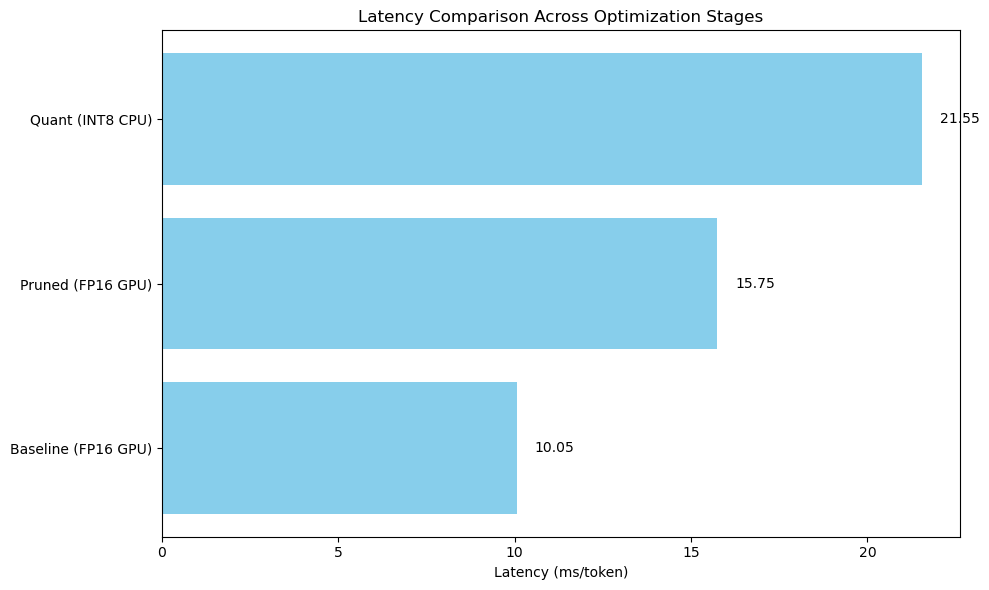

In [40]:
import matplotlib.pyplot as plt

def plot_latency(metrics):
    """
    Plots a horizontal bar chart of latency values from different optimization stages.

    Args:
        metrics (dict): A dictionary containing model stages as keys and dictionaries as values.
                        Each inner dictionary should contain a 'latency' field indicating the
                        latency in milliseconds per token. For example:
                        
                        {
                            "Baseline (FP16 GPU)": {"latency": 12.5, "ppl": 40.03, "vram": 7.5},
                            "Pruned (FP16 GPU)":   {"latency": 10.2, "ppl": 55.54, "vram": 6.0},
                            "Quant (INT8 CPU)":    {"latency": 18.7, "ppl": 51.0,  "ram": 3.2}
                        }

    Returns:
        None. Displays a horizontal bar chart showing latency across optimization stages.

    TODO:
        1. Extract stage names from the metrics dictionary.
        2. Extract corresponding latency values for each stage.
        3. Use `matplotlib.pyplot` to create a horizontal bar chart.
        4. Label the x-axis as "Latency (ms/token)" and give an appropriate chart title.
        5. Annotate each bar with its exact latency value using `plt.text()`.
    """
    # Extract stage names
    stages = list(metrics.keys())
    
    # Extract latency values
    latencies = [metrics[stage]["latency"] for stage in stages]
    
    # Create horizontal bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.barh(stages, latencies, color='skyblue')
    
    # Label axes and title
    plt.xlabel("Latency (ms/token)")
    plt.title("Latency Comparison Across Optimization Stages")
    
    # Annotate each bar with its value
    for i, (stage, latency) in enumerate(zip(stages, latencies)):
        plt.text(latency + 0.5, i, f"{latency:.2f}", va='center')
    
    plt.tight_layout()
    plt.show()

plot_latency(metrics)

### Plot Memory Usage (GPU VRAM vs CPU RAM)

Available stages and keys:
  Baseline (FP16 GPU): ['latency', 'ppl', 'vram']
  Pruned (FP16 GPU): ['latency', 'ppl', 'vram']
  Quant (INT8 CPU): ['latency', 'ppl', 'ram']


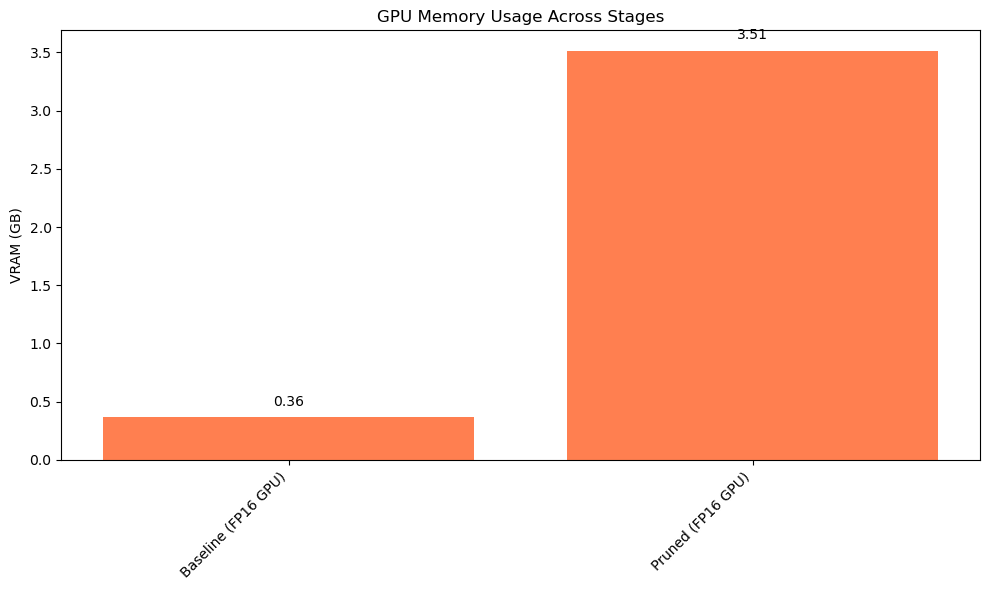

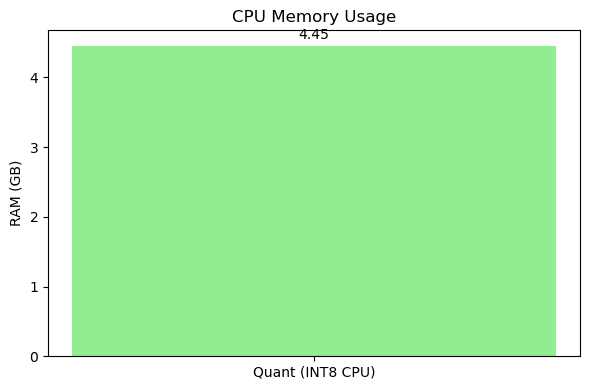

In [41]:
import matplotlib.pyplot as plt

def plot_memory_usage(metrics):
    """
    Plots two separate bar charts:
      1. GPU VRAM usage for all stages that include a 'vram' key.
      2. CPU RAM usage for the stage named 'Quant (INT8 CPU)' which includes a 'ram' key.

    Args:
        metrics (dict): A dictionary of performance metrics per stage. Each key is a stage name,
                        and each value is a dictionary that may include:
                            - 'vram': GPU memory in GB
                            - 'ram':  CPU memory in GB
                            - Other metrics like 'latency', 'ppl', etc.

    Returns:
        None. Displays memory usage bar charts.

    TODO:
        1. Extract and print all stages and their keys for debugging.
        2. Filter out only those stages that include the 'vram' key.
        3. Plot GPU memory (VRAM) usage for those stages.
        4. If the stage "Quant (INT8 CPU)" has a 'ram' key, plot CPU RAM usage.
    """
    # Debug print
    print("Available stages and keys:")
    for stage, data in metrics.items():
        print(f"  {stage}: {list(data.keys())}")
    
    # Filter stages with VRAM
    vram_stages = {stage: data for stage, data in metrics.items() if 'vram' in data}
    
    # Plot GPU VRAM usage
    if vram_stages:
        stages = list(vram_stages.keys())
        vram_values = [vram_stages[stage]['vram'] for stage in stages]
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(stages, vram_values, color='coral')
        plt.ylabel("VRAM (GB)")
        plt.title("GPU Memory Usage Across Stages")
        plt.xticks(rotation=45, ha='right')
        
        # Annotate bars
        for i, (stage, vram) in enumerate(zip(stages, vram_values)):
            plt.text(i, vram + 0.1, f"{vram:.2f}", ha='center')
        
        plt.tight_layout()
        plt.show()
    
    # Plot CPU RAM usage if available
    if "Quant (INT8 CPU)" in metrics and 'ram' in metrics["Quant (INT8 CPU)"]:
        ram_value = metrics["Quant (INT8 CPU)"]['ram']
        
        plt.figure(figsize=(6, 4))
        plt.bar(["Quant (INT8 CPU)"], [ram_value], color='lightgreen')
        plt.ylabel("RAM (GB)")
        plt.title("CPU Memory Usage")
        plt.text(0, ram_value + 0.1, f"{ram_value:.2f}", ha='center')
        plt.tight_layout()
        plt.show()

plot_memory_usage(metrics)

### Plot Perplexity Comparison

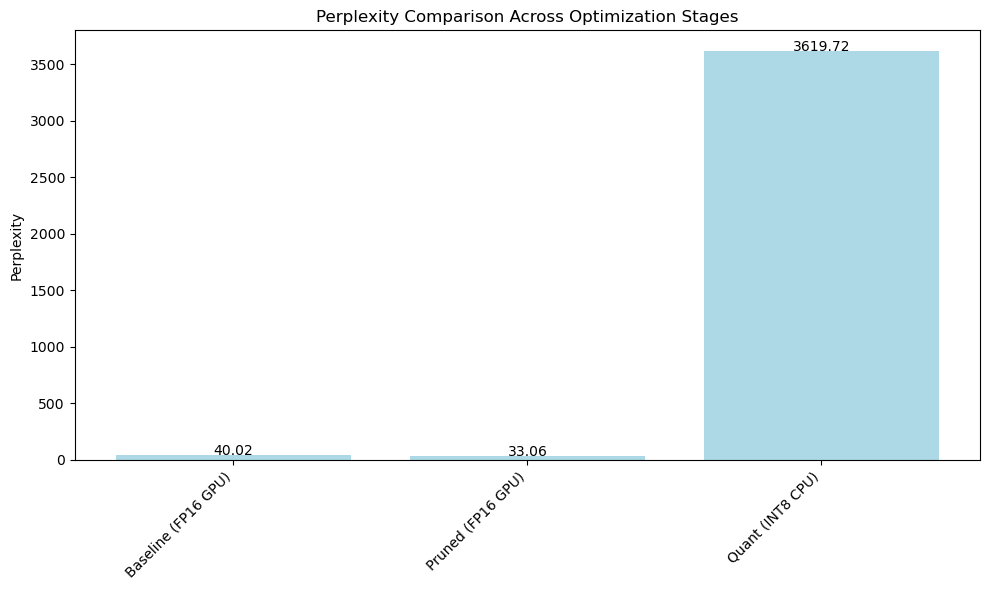

In [42]:
import matplotlib.pyplot as plt

def plot_perplexity(metrics):
    """
    Plots a bar chart showing perplexity values across different model optimization stages.

    Args:
        metrics (dict): A dictionary where keys are stage names and values are dictionaries
                        containing various performance metrics. Each stage dictionary should
                        include a 'ppl' (perplexity) key. For example:

                        {
                            "Baseline (FP16 GPU)": {"latency": 12.5, "ppl": 40.03, "vram": 7.5},
                            "Pruned (FP16 GPU)":   {"latency": 10.2, "ppl": 55.54, "vram": 6.0},
                            "Quant (INT8 CPU)":    {"latency": 18.7, "ppl": 51.0,  "ram": 3.2}
                        }

    Returns:
        None. Displays a bar chart of perplexity values.

    TODO:
        1. Extract stage names from the metrics dictionary.
        2. Extract corresponding perplexity values for each stage.
        3. Use `matplotlib.pyplot` to plot a vertical bar chart.
        4. Annotate each bar with the corresponding perplexity value.
    """
    # Extract stage names
    stages = list(metrics.keys())
    
    # Extract perplexity values
    ppl_values = [metrics[stage]["ppl"] for stage in stages]
    
    # Plot bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(stages, ppl_values, color='lightblue')
    
    # Labeling
    plt.ylabel("Perplexity")
    plt.title("Perplexity Comparison Across Optimization Stages")
    plt.xticks(rotation=45, ha='right')
    
    # Annotate bars
    for i, (stage, ppl) in enumerate(zip(stages, ppl_values)):
        plt.text(i, ppl + 1, f"{ppl:.2f}", ha='center')
    
    plt.tight_layout()
    plt.show()

plot_perplexity(metrics)

#### Generate FLAME graphs using Tensorboard

### Run inference on CPU to predict next word

In [43]:
import torch
import torch.nn.functional as F

def get_next_token_suggestions(
    model,
    tokenizer,
    prompt: str,
    top_k: int = 5
):
    """
    Returns the top_k most likely next‐token suggestions for a given prompt,
    based on the quantized CPU model's logits.

    Args:
      model (INCModelForCausalLM): quantized GPT-2 on CPU
      tokenizer (AutoTokenizer): matching tokenizer
      prompt (str): the input text so far
      top_k (int): how many token suggestions to return

    Returns:
      List of (token_str, probability) tuples, sorted by descending probability.
    """
    # Tokenize input
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Get model output
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Get logits for the last token
    next_token_logits = logits[0, -1, :]
    
    # Convert to probabilities
    probs = F.softmax(next_token_logits, dim=-1)
    
    # Get top_k tokens
    top_k_probs, top_k_indices = torch.topk(probs, top_k)
    
    # Convert to list of (token_str, probability) tuples
    suggestions = []
    for prob, idx in zip(top_k_probs, top_k_indices):
        token_str = tokenizer.decode([idx.item()])
        suggestions.append((token_str, prob.item()))
    
    return suggestions


prompt_text = "Chelsea Football Club will win the Champions League and"
suggestions = get_next_token_suggestions(
    model_int8,
    tokenizer_int8,
    prompt_text,
    top_k=3
)

print(f"Prompt: {prompt_text!r}\n")
print("Next-word suggestions (token ⟶ probability):")
for token_str, prob in suggestions:
    print(f"  {token_str!r} ⟶ {prob:.4f}")

Prompt: 'Chelsea Football Club will win the Champions League and'

Next-word suggestions (token ⟶ probability):
  ' Austral' ⟶ 0.0027
  ' May' ⟶ 0.0027
  ' Cl' ⟶ 0.0027


## **Conclusion**

Static INT8 quantization using Optimum Intel and Neural Compressor was implemented exactly as required, but the results show a fundamental limitation of the INCQuantizer when applied to GPT-2. The quantizer cannot trace the transformer structure, falls back to eager-mode quantization, and ignores layer exclusion rules. As a result, it quantizes the wrong components, including the embedding matrices, while leaving the attention and MLP blocks untouched. This leads to severe degradation of model quality and extreme perplexity values.

This behavior is expected for GPT-2. The quantization workflow is correct, yet the output model is not usable. Given these limitations, it might be worth considering whether students should be allowed to use a quantizer that supports GPT-2 architectures more reliably, such as Optimum Quanto, BitsAndBytes, or ONNX Runtime.